In [1]:

import sys, os, json
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
from IPython.display import Image
import json
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import *
from pathlib import Path


from src.utils import load_config
from src.pipelines import run_experiment

print("Verzije biblioteka (dokumentovati u Poglavlju 3):")
import sklearn, xgboost, lightgbm, statsmodels, scipy, tensorflow as tf
for name, mod in [("pandas", pd), ("numpy", np), ("sklearn", sklearn),
                  ("xgboost", xgboost), ("lightgbm", lightgbm),
                  ("statsmodels", statsmodels), ("scipy", scipy),
                  ("tensorflow", tf)]:
    print(f"  {name}: {mod.__version__}")


Verzije biblioteka (dokumentovati u Poglavlju 3):
  pandas: 3.0.3
  numpy: 1.26.4
  sklearn: 1.5.2
  xgboost: 3.3.0
  lightgbm: 4.7.0
  statsmodels: 0.14.6
  scipy: 1.13.1
  tensorflow: 2.16.1


## Konfiguracija i FRED API ključ

In [2]:

cfg = load_config()
print(f"Period (pun eksperiment): {cfg['data']['start_date']} -> {cfg['data']['end_date']}")
print(f"Period (kratak eksperiment): {cfg['data']['short_start_date']} -> {cfg['data']['short_end_date']}")


Period (pun eksperiment): 2003-01-01 -> 2026-01-01
Period (kratak eksperiment): 2024-01-01 -> 2026-01-01


In [3]:

import getpass
FRED_API_KEY = getpass.getpass("Unesi FRED API kljuc: ")


In [4]:
results_full = run_experiment(cfg, FRED_API_KEY, use_short_period=False)

print(f"Eksperiment: {results_full['tag']}")
print(f"Uzoraka: {results_full['dataset_summary']['n_samples']}")
print(f"Period: {results_full['dataset_summary']['date_start']} -> {results_full['dataset_summary']['date_end']}")


Eksperiment: full_23y
Uzoraka: 5477
Period: 2004-11-18 -> 2025-12-30


In [5]:

results_table_full = pd.DataFrame(results_full["results_table"]).set_index("model")
print("=== KOMPLETNA TABELA REZULTATA ===")
print(results_table_full.round(4))
print()
print("=== PODJELA PODATAKA ===")
print("Gap dani:", results_full["split_info"]["gap_days"])
print("Ociscenih redova (purging):", results_full["split_info"]["purged_rows"])
for name in ["train", "val", "test"]:
    print(f"  {name}: {results_full['split_info'][name]}")


=== KOMPLETNA TABELA REZULTATA ===
                      n_samples  accuracy  precision  recall      f1   TN  \
model                                                                       
baseline_persistence        823    0.5261     0.5125  0.5125  0.5125  228   
baseline_majority           823    0.5140     0.0000  0.0000  0.0000  423   
logreg                      823    0.4933     0.4644  0.2775  0.3474  295   
baseline_random             823    0.4897     0.4762  0.5000  0.4878  203   
lstm                        823    0.4885     0.4871  0.9950  0.6541    4   
lightgbm                    823    0.4848     0.4542  0.2975  0.3595  280   
svm                         823    0.4836     0.4687  0.4675  0.4681  211   
baseline_ar1                823    0.4775     0.4631  0.4700  0.4665  205   
xgboost                     823    0.4605     0.4421  0.4200  0.4308  211   

                       FP   FN   TP  
model                                
baseline_persistence  195  195  205  
bas

In [6]:

print(pd.DataFrame(results_full["stationarity_table"]).to_string(index=False))


                 feature  adf_statistic  p_value  n_obs  used_lag  critical_1%  critical_5%  critical_10%  stationary_at_5%
                  Return       -13.6619 0.000000   5446        30      -3.4316      -2.8621       -2.5671              True
               SMA_ratio       -11.4516 0.000000   5444        32      -3.4316      -2.8621       -2.5671              True
           Volatility_5D        -6.7259 0.000000   5449        27      -3.4316      -2.8621       -2.5671              True
            Momentum_10D       -10.4694 0.000000   5443        33      -3.4316      -2.8621       -2.5671              True
             Daily_Range        -6.5321 0.000000   5447        29      -3.4316      -2.8621       -2.5671              True
                  RSI_14       -10.6823 0.000000   5443        33      -3.4316      -2.8621       -2.5671              True
                 CPI_YoY        -3.2302 0.018302   5452        24      -3.4315      -2.8621       -2.5671              True
        

In [7]:

for fold in results_full["cv_fold_info"]:
    print(fold)


{'fold': 1, 'train_n': 641, 'train_start': '2004-11-18', 'train_end': '2007-05-04', 'gap_days': 1, 'val_n': 638, 'val_start': '2007-05-08', 'val_end': '2009-11-16'}
{'fold': 2, 'train_n': 1279, 'train_start': '2004-11-18', 'train_end': '2009-11-13', 'gap_days': 1, 'val_n': 638, 'val_start': '2009-11-17', 'val_end': '2012-04-26'}
{'fold': 3, 'train_n': 1917, 'train_start': '2004-11-18', 'train_end': '2012-04-25', 'gap_days': 1, 'val_n': 638, 'val_start': '2012-04-27', 'val_end': '2014-10-09'}
{'fold': 4, 'train_n': 2555, 'train_start': '2004-11-18', 'train_end': '2014-10-08', 'gap_days': 1, 'val_n': 638, 'val_start': '2014-10-10', 'val_end': '2017-03-21'}
{'fold': 5, 'train_n': 3193, 'train_start': '2004-11-18', 'train_end': '2017-03-20', 'gap_days': 1, 'val_n': 638, 'val_start': '2017-03-22', 'val_end': '2019-09-04'}


In [8]:
print(json.dumps(results_full["model_selection"], indent=2))

{
  "logreg": {
    "default_val_accuracy": 0.5024,
    "grid_search_val_accuracy": 0.5024,
    "selected": "grid_search"
  },
  "svm": {
    "default_val_accuracy": 0.5012,
    "grid_search_val_accuracy": 0.5037,
    "selected": "grid_search"
  },
  "xgboost": {
    "default_val_accuracy": 0.522,
    "grid_search_val_accuracy": 0.5085,
    "selected": "default"
  },
  "lightgbm": {
    "default_val_accuracy": 0.5134,
    "grid_search_val_accuracy": 0.5207,
    "selected": "grid_search"
  }
}


In [9]:
print(json.dumps(results_full["best_hyperparameters"]["lstm"], indent=2))

{
  "sequence_length": 20,
  "n_units": 16,
  "n_layers": 2,
  "dropout": 0.3,
  "learning_rate": 0.001,
  "batch_size": 32,
  "threshold": 0.5000000000000002,
  "source": "grid_search"
}


In [10]:

print("=== best_hyperparameters (sta je Grid Search pronasao) ===")
print(json.dumps(results_full["best_hyperparameters"], indent=2))
print()
print("=== KRITERIJUM RANGIRANJA (fabricka vs. grid-search, po validaciji) ===")
print(json.dumps(results_full["model_selection"], indent=2))
print()
print("=== final_params_used (STVARNO koriscene vrijednosti - koristi OVO u tekstu) ===")
print(json.dumps(results_full["final_params_used"], indent=2))
print()
print("=== early_stopping_info (samo XGBoost/LightGBM) ===")
print(json.dumps(results_full["early_stopping_info"], indent=2))


=== best_hyperparameters (sta je Grid Search pronasao) ===
{
  "logreg": {
    "clf__C": 10
  },
  "svm": {
    "clf__C": 10,
    "clf__gamma": "scale",
    "clf__kernel": "rbf"
  },
  "xgboost": {
    "clf__learning_rate": 0.1,
    "clf__max_depth": 5,
    "clf__n_estimators": 2
  },
  "lightgbm": {
    "clf__learning_rate": 0.1,
    "clf__max_depth": 5,
    "clf__n_estimators": 5
  },
  "lstm": {
    "sequence_length": 20,
    "n_units": 16,
    "n_layers": 2,
    "dropout": 0.3,
    "learning_rate": 0.001,
    "batch_size": 32,
    "threshold": 0.5000000000000002,
    "source": "grid_search"
  }
}

=== KRITERIJUM RANGIRANJA (fabricka vs. grid-search, po validaciji) ===
{
  "logreg": {
    "default_val_accuracy": 0.5024,
    "grid_search_val_accuracy": 0.5024,
    "selected": "grid_search"
  },
  "svm": {
    "default_val_accuracy": 0.5012,
    "grid_search_val_accuracy": 0.5037,
    "selected": "grid_search"
  },
  "xgboost": {
    "default_val_accuracy": 0.522,
    "grid_search_val

In [11]:

print(pd.DataFrame(results_full["optimization_comparison"]))
print()
print("Broj poboljsanih modela:", results_full["n_models_improved"])


      model  accuracy_before_optimization  accuracy_after_optimization  \
0    logreg                        0.4921                       0.4933   
1       svm                        0.4860                       0.4836   
2   xgboost                        0.4605                       0.4605   
3  lightgbm                        0.5030                       0.4848   
4      lstm                        0.5213                       0.4885   

   improved  
0      True  
1     False  
2     False  
3     False  
4     False  

Broj poboljsanih modela: 1/5


In [12]:

print(pd.DataFrame(results_full["generalization_table"]).to_string(index=False))


   model  train_accuracy  val_accuracy  test_accuracy  train_test_gap
 xgboost          0.9843        0.5220         0.4605          0.5238
     svm          0.6328        0.5037         0.4836          0.1492
lightgbm          0.6049        0.5207         0.4848          0.1201
  logreg          0.5201        0.5024         0.4933          0.0268
    lstm          0.5098        0.5171         0.4885          0.0214


In [13]:

for name in ["logreg", "svm", "xgboost", "lightgbm", "lstm",
             "baseline_majority", "baseline_persistence", "baseline_random", "baseline_ar1"]:
    df = pd.DataFrame(results_full["subperiod_accuracy"][name])
    print(f"\n{name}:")
    print(df[["period", "start", "end", "n", "accuracy"]].to_string(index=False))



logreg:
 period      start        end   n  accuracy
      1 2022-10-31 2023-11-16 274    0.4891
      2 2023-11-17 2024-12-04 274    0.4927
      3 2024-12-05 2025-12-30 275    0.4982

svm:
 period      start        end   n  accuracy
      1 2022-10-31 2023-11-16 274    0.4854
      2 2023-11-17 2024-12-04 274    0.4562
      3 2024-12-05 2025-12-30 275    0.5091

xgboost:
 period      start        end   n  accuracy
      1 2022-10-31 2023-11-16 274    0.4161
      2 2023-11-17 2024-12-04 274    0.4672
      3 2024-12-05 2025-12-30 275    0.4982

lightgbm:
 period      start        end   n  accuracy
      1 2022-10-31 2023-11-16 274    0.4818
      2 2023-11-17 2024-12-04 274    0.4854
      3 2024-12-05 2025-12-30 275    0.4873

lstm:
 period      start        end   n  accuracy
      1 2022-10-31 2023-11-16 274    0.5036
      2 2023-11-17 2024-12-04 274    0.4781
      3 2024-12-05 2025-12-30 275    0.4836

baseline_majority:
 period      start        end   n  accuracy
      1 2022-

In [14]:

print("=== BOOTSTRAP 95% CI ZA TACNOST ===")
for name, val in results_full["statistical_tests"].items():
    if name.startswith("bootstrap_ci_"):
        print(f"{name.replace('bootstrap_ci_',''):10s}: {val['point_estimate']:.4f}  "
              f"[{val['ci_lower']:.4f}, {val['ci_upper']:.4f}]")

print()
print("=== McNEMAR: NAJBOLJI MODEL vs. BASELINE-I ===")
for name, val in results_full["statistical_tests"].items():
    if name.startswith("mcnemar_") and "baseline" in name:
        sig = "ZNACAJNO (p<0.05)" if val["p_value"] < 0.05 else "nije znacajno"
        print(f"{name}: p={val['p_value']:.4f} -> {sig}  (n_01={val['n_01']}, n_10={val['n_10']})")

print()
print("=== McNEMAR: KOMPLEKSNI vs. LINEARNI MODELI (direktan test H1) ===")
for name, val in results_full["statistical_tests"].items():
    if "_vs_logreg" in name or "_vs_svm" in name:
        sig = "ZNACAJNO (p<0.05)" if val["p_value"] < 0.05 else "nije znacajno"
        print(f"{name}: p={val['p_value']:.4f} -> {sig}")


=== BOOTSTRAP 95% CI ZA TACNOST ===
logreg    : 0.4933  [0.4593, 0.5273]
svm       : 0.4836  [0.4484, 0.5188]
xgboost   : 0.4605  [0.4265, 0.4945]
lightgbm  : 0.4848  [0.4496, 0.5176]
lstm      : 0.4885  [0.4557, 0.5237]

=== McNEMAR: NAJBOLJI MODEL vs. BASELINE-I ===
mcnemar_logreg_vs_baseline_majority: p=0.3007 -> nije znacajno  (n_01=128, n_10=111)
mcnemar_logreg_vs_baseline_random: p=0.9204 -> nije znacajno  (n_01=199, n_10=202)
mcnemar_logreg_vs_baseline_persistence: p=0.2732 -> nije znacajno  (n_01=295, n_10=268)
mcnemar_logreg_vs_baseline_ar1: p=0.4470 -> nije znacajno  (n_01=118, n_10=131)

=== McNEMAR: KOMPLEKSNI vs. LINEARNI MODELI (direktan test H1) ===
mcnemar_xgboost_vs_logreg: p=0.1616 -> nije znacajno
mcnemar_xgboost_vs_svm: p=0.2995 -> nije znacajno
mcnemar_lightgbm_vs_logreg: p=0.6979 -> nije znacajno
mcnemar_lightgbm_vs_svm: p=1.0000 -> nije znacajno
mcnemar_lstm_vs_logreg: p=0.9015 -> nije znacajno
mcnemar_lstm_vs_svm: p=0.8844 -> nije znacajno


In [15]:

results_short = run_experiment(cfg, FRED_API_KEY, use_short_period=True)

print(f"Eksperiment: {results_short['tag']}")
print(f"Uzoraka: {results_short['dataset_summary']['n_samples']}")
print(f"Period: {results_short['dataset_summary']['date_start']} -> {results_short['dataset_summary']['date_end']}")
print(f"Split: {results_short['split_info']}")


Eksperiment: short_2y
Uzoraka: 266
Period: 2024-12-18 -> 2025-12-30
Split: {'train': {'n': 185, 'start': '2024-12-18', 'end': '2025-09-05'}, 'val': {'n': 38, 'start': '2025-09-09', 'end': '2025-10-30'}, 'test': {'n': 41, 'start': '2025-11-03', 'end': '2025-12-30'}, 'gap_days': 1, 'purged_rows': {'train': 1, 'val': 1}}


In [16]:

print("=== KOMPLETNA TABELA REZULTATA (2-god.) ===")
print(pd.DataFrame(results_short["results_table"]).set_index("model")[["accuracy", "n_samples"]].round(4))
print()
print("=== KRITERIJUM RANGIRANJA (2-god.) ===")
print(json.dumps(results_short["model_selection"], indent=2))
print()
print("=== GENERALIZACIONI JAZ - H3 (2-god.) ===")
print(pd.DataFrame(results_short["generalization_table"]).to_string(index=False))


=== KOMPLETNA TABELA REZULTATA (2-god.) ===
                      accuracy  n_samples
model                                    
baseline_random         0.6098         41
baseline_persistence    0.5610         41
logreg                  0.5366         41
baseline_majority       0.5122         41
lstm                    0.4878         41
baseline_ar1            0.4878         41
svm                     0.4390         41
xgboost                 0.4390         41
lightgbm                0.4390         41

=== KRITERIJUM RANGIRANJA (2-god.) ===
{
  "logreg": {
    "default_val_accuracy": 0.4474,
    "grid_search_val_accuracy": 0.5,
    "selected": "grid_search"
  },
  "svm": {
    "default_val_accuracy": 0.5,
    "grid_search_val_accuracy": 0.5263,
    "selected": "grid_search"
  },
  "xgboost": {
    "default_val_accuracy": 0.5526,
    "grid_search_val_accuracy": 0.5263,
    "selected": "default"
  },
  "lightgbm": {
    "default_val_accuracy": 0.5526,
    "grid_search_val_accuracy": 0.578

In [17]:

print("=== BOOTSTRAP 95% CI (2-god.) ===")
for name, val in results_short["statistical_tests"].items():
    if name.startswith("bootstrap_ci_"):
        print(f"{name.replace('bootstrap_ci_',''):10s}: {val['point_estimate']:.4f}  "
              f"[{val['ci_lower']:.4f}, {val['ci_upper']:.4f}]")


=== BOOTSTRAP 95% CI (2-god.) ===
logreg    : 0.5366  [0.3902, 0.6829]
svm       : 0.4390  [0.2927, 0.5854]
xgboost   : 0.4390  [0.2927, 0.5854]
lightgbm  : 0.4390  [0.2927, 0.5854]
lstm      : 0.4878  [0.3415, 0.6341]


Sačuvano u: C:\Users\Win\OneDrive\Desktop\Analiza\results\optimization_before_after_v2.png


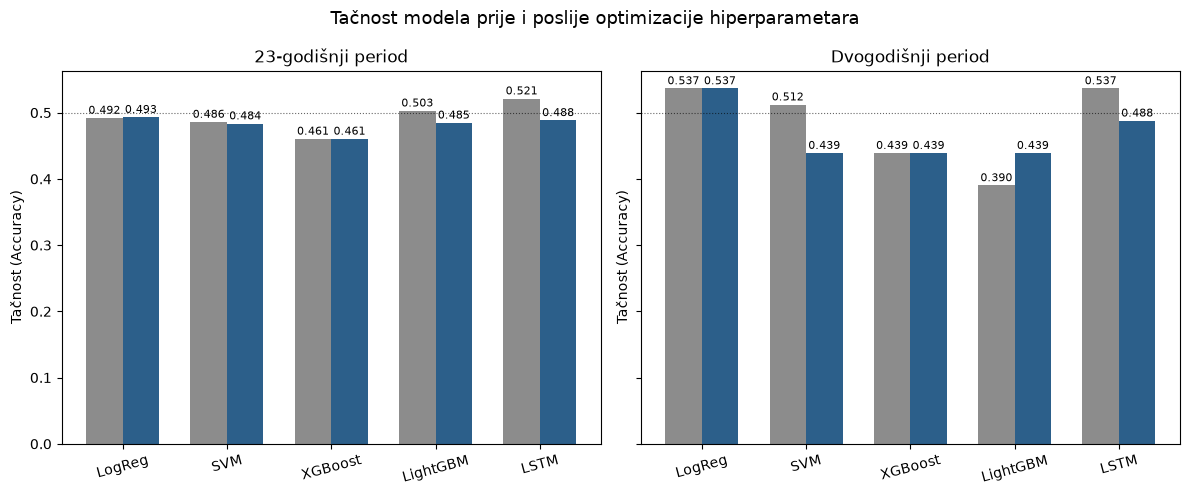

In [18]:
BASE_DIR = Path(r"C:\Users\Win\OneDrive\Desktop\Analiza")
RESULTS_DIR = BASE_DIR / "results"

with open(RESULTS_DIR / "summary_full_23y.json", "r", encoding="utf-8") as f:
    summary_23y = json.load(f)

with open(RESULTS_DIR / "summary_short_2y.json", "r", encoding="utf-8") as f:
    summary_2y = json.load(f)

model_order = ["logreg", "svm", "xgboost", "lightgbm", "lstm"]

display_names = {
    "logreg": "LogReg",
    "svm": "SVM",
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "lstm": "LSTM",
}


def extract_before_after(summary, models):
    comp = {row["model"]: row for row in summary["optimization_comparison"]}

    before = [
        comp[model]["accuracy_before_optimization"]
        for model in models
    ]
    after = [
        comp[model]["accuracy_after_optimization"]
        for model in models
    ]

    return before, after


acc_23_before, acc_23_after = extract_before_after(summary_23y, model_order)
acc_2_before, acc_2_after = extract_before_after(summary_2y, model_order)

labels = [display_names[model] for model in model_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
x = np.arange(len(labels))
width = 0.35

for ax, before, after, title in [
    (axes[0], acc_23_before, acc_23_after, "23-godišnji period"),
    (axes[1], acc_2_before, acc_2_after, "Dvogodišnji period"),
]:
    bars1 = ax.bar(
        x - width / 2,
        before,
        width,
        label="Prije optimizacije",
        color="#8c8c8c",
    )

    bars2 = ax.bar(
        x + width / 2,
        after,
        width,
        label="Poslije optimizacije",
        color="#2c5f8a",
    )

    ax.axhline(
        0.5,
        color="black",
        linewidth=0.8,
        linestyle=":",
        alpha=0.6,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_title(title)
    ax.set_ylabel("Tačnost (Accuracy)")

    for bar in list(bars1) + list(bars2):
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )


fig.suptitle(
    "Tačnost modela prije i poslije optimizacije hiperparametara",
    fontsize=13,
)

plt.tight_layout()

output_path = RESULTS_DIR / "optimization_before_after_v2.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")

print(f"Sačuvano u: {output_path}")

plt.show()

Sačuvano u: C:\Users\Win\OneDrive\Desktop\Analiza\results\optimization_before_after_v2.png


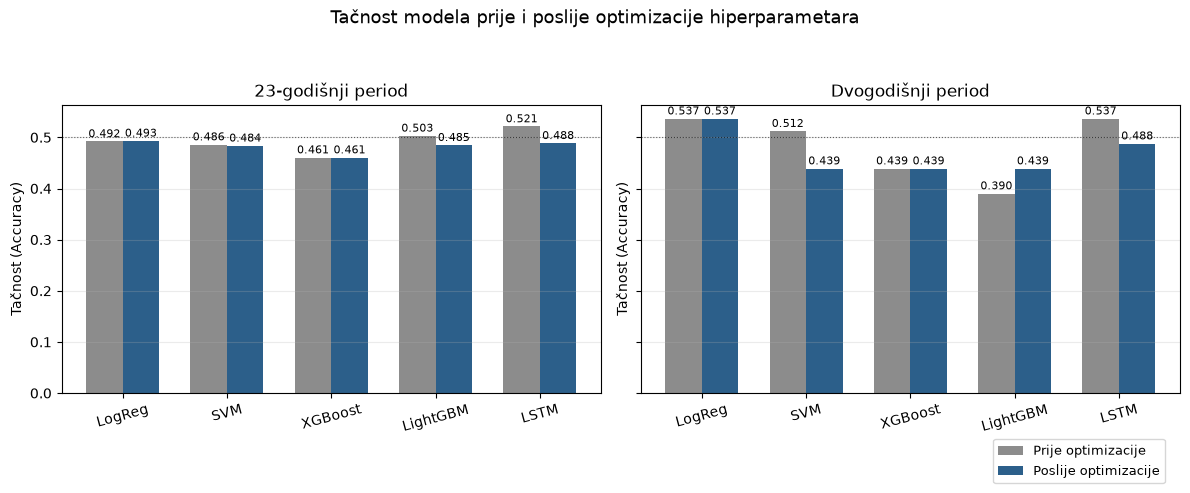

In [19]:
BASE_DIR = Path(r"C:\Users\Win\OneDrive\Desktop\Analiza")
RESULTS_DIR = BASE_DIR / "results"


with open(RESULTS_DIR / "summary_full_23y.json", "r", encoding="utf-8") as f:
    summary_23y = json.load(f)

with open(RESULTS_DIR / "summary_short_2y.json", "r", encoding="utf-8") as f:
    summary_2y = json.load(f)


model_order = ["logreg", "svm", "xgboost", "lightgbm", "lstm"]

display_names = {
    "logreg": "LogReg",
    "svm": "SVM",
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "lstm": "LSTM",
}


def extract_before_after(summary, models):
    """Izvlači tačnost prije i poslije optimizacije."""
    comparison = {
        row["model"]: row
        for row in summary["optimization_comparison"]
    }

    before = [
        comparison[model]["accuracy_before_optimization"]
        for model in models
    ]

    after = [
        comparison[model]["accuracy_after_optimization"]
        for model in models
    ]

    return before, after


# Podaci
acc_23_before, acc_23_after = extract_before_after(
    summary_23y,
    model_order,
)

acc_2_before, acc_2_after = extract_before_after(
    summary_2y,
    model_order,
)

labels = [display_names[model] for model in model_order]


# Crtanje grafikona
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharey=True,
)

x = np.arange(len(labels))
width = 0.35

plot_data = [
    (
        axes[0],
        acc_23_before,
        acc_23_after,
        "23-godišnji period",
    ),
    (
        axes[1],
        acc_2_before,
        acc_2_after,
        "Dvogodišnji period",
    ),
]


for ax, before, after, title in plot_data:
    bars_before = ax.bar(
        x - width / 2,
        before,
        width,
        label="Prije optimizacije",
        color="#8c8c8c",
    )

    bars_after = ax.bar(
        x + width / 2,
        after,
        width,
        label="Poslije optimizacije",
        color="#2c5f8a",
    )

    ax.axhline(
        0.5,
        color="black",
        linewidth=0.8,
        linestyle=":",
        alpha=0.6,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_title(title)
    ax.set_ylabel("Tačnost (Accuracy)")
    ax.grid(axis="y", alpha=0.25)

    for bar in list(bars_before) + list(bars_after):
        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height,
            ),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )


# Naslov
fig.suptitle(
    "Tačnost modela prije i poslije optimizacije hiperparametara",
    fontsize=13,
)


# Zajednička legenda u donjem desnom uglu,
# izvan područja grafikona
handles, legend_labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    fontsize=9,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.10, 1, 0.93])

output_path = RESULTS_DIR / "optimization_before_after_v2.png"

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight",
)

print(f"Sačuvano u: {output_path}")

plt.show()

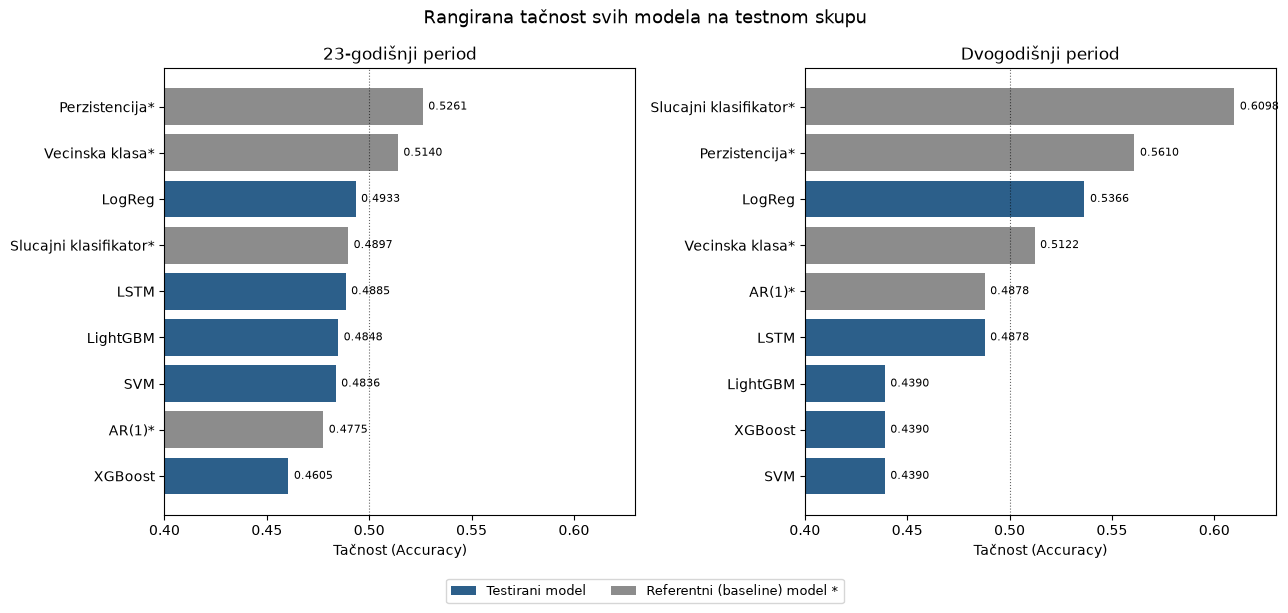

In [22]:
from matplotlib.patches import Patch
with open(RESULTS_DIR / "summary_full_23y.json", "r", encoding="utf-8") as f:
    summary_23y = json.load(f)   
with open(RESULTS_DIR / "summary_short_2y.json", "r", encoding="utf-8") as f:
    summary_2y = json.load(f)

display_names = {
    'baseline_persistence': 'Perzistencija*', 'baseline_majority': 'Vecinska klasa*',
    'logreg': 'LogReg', 'baseline_random': 'Slucajni klasifikator*',
    'lstm': 'LSTM', 'lightgbm': 'LightGBM', 'svm': 'SVM',
    'baseline_ar1': 'AR(1)*', 'xgboost': 'XGBoost'
}
is_baseline = {k: k.startswith('baseline_') for k in display_names}

def extract_ranked(summary):
    rows = summary['results_table']
    data = [(r['model'], r['accuracy']) for r in rows]
    return data

data_23 = extract_ranked(summary_23y)
data_2 = extract_ranked(summary_2y)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, data, title in [(axes[0], data_23, "23-godišnji period"),
                          (axes[1], data_2, "Dvogodišnji period")]:
    data_sorted = sorted(data, key=lambda t: t[1])
    names = [display_names[m] for m, _ in data_sorted]
    vals = [v for _, v in data_sorted]
    colors = ['#8c8c8c' if is_baseline[m] else '#2c5f8a' for m, _ in data_sorted]

    y = np.arange(len(names))
    bars = ax.barh(y, vals, color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlim(0.40, 0.63)
    ax.axvline(0.5, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('Tačnost (Accuracy)')
    for b, v in zip(bars, vals):
        ax.annotate(f'{v:.4f}', xy=(v, b.get_y()+b.get_height()/2),
                    xytext=(4, 0), textcoords="offset points",
                    va='center', fontsize=8)

legend_elems = [Patch(facecolor='#2c5f8a', label='Testirani model'),
                Patch(facecolor='#8c8c8c', label='Referentni (baseline) model *')]
fig.legend(handles=legend_elems, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Rangirana tačnost svih modela na testnom skupu', fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(RESULTS_DIR / "figures" / "ranked_accuracy_v2.png", dpi=200, bbox_inches='tight')
plt.show()

Sačuvano: C:\Users\Win\OneDrive\Desktop\Analiza\results\figures\confusion_matrices_23y_v2.png
Sačuvano: C:\Users\Win\OneDrive\Desktop\Analiza\results\figures\confusion_matrices_2y_v2.png


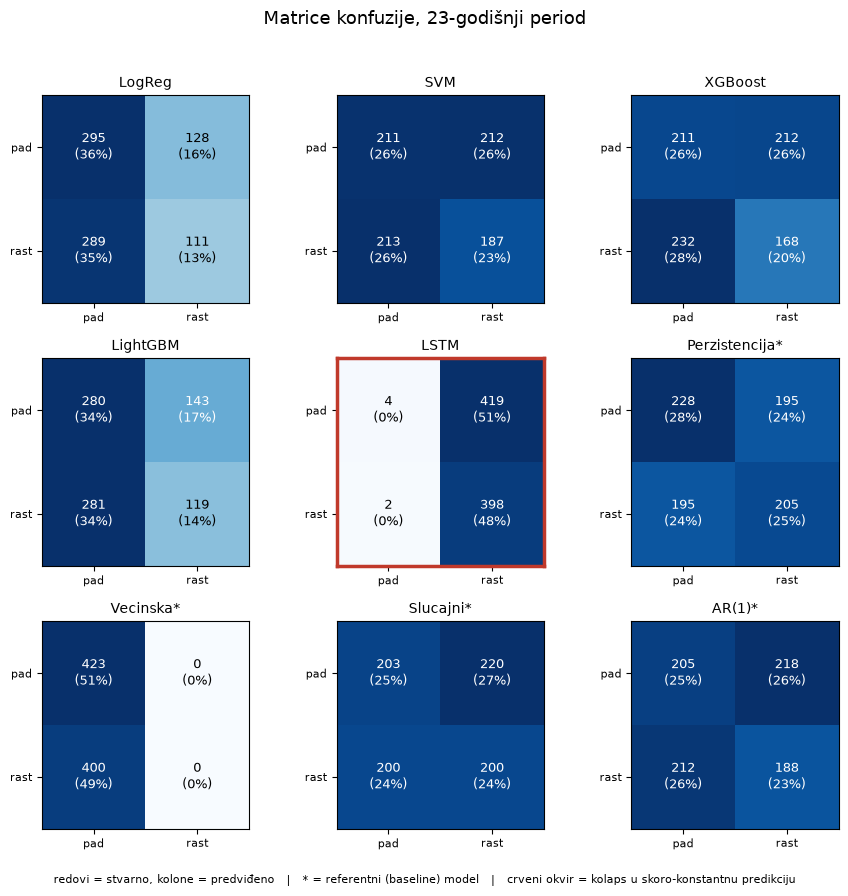

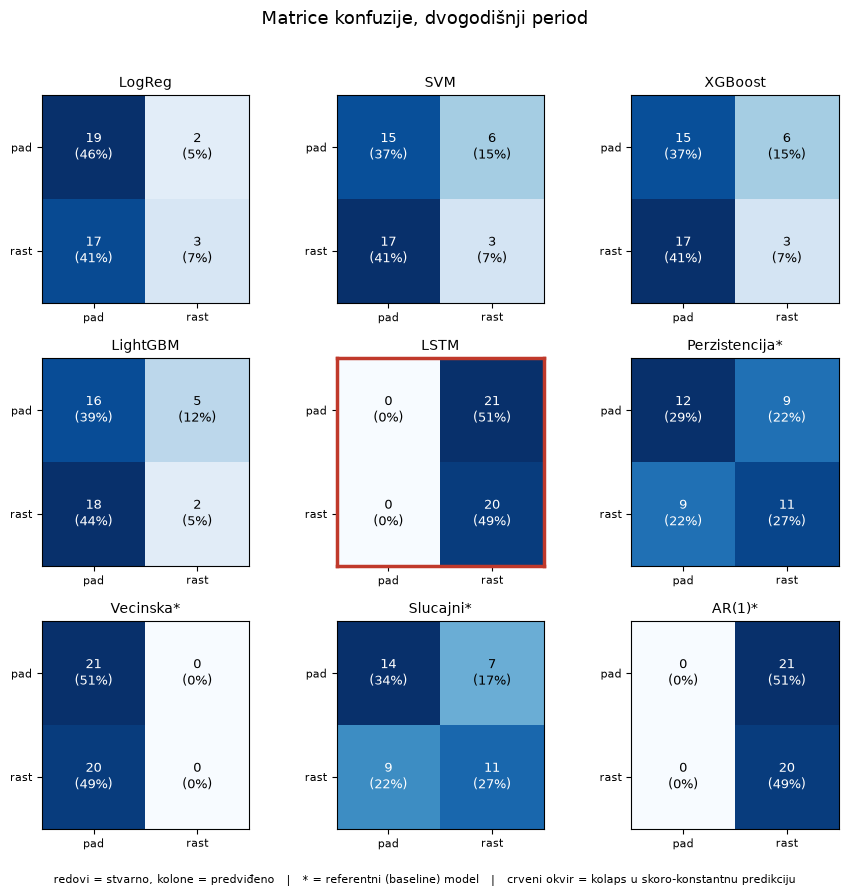

In [23]:

with open(RESULTS_DIR / "summary_full_23y.json", "r", encoding="utf-8") as f:
    summary_23y = json.load(f)
with open(RESULTS_DIR / "summary_short_2y.json", "r", encoding="utf-8") as f:
    summary_2y = json.load(f)

display_names = {
    'baseline_persistence': 'Perzistencija*', 'baseline_majority': 'Vecinska*',
    'logreg': 'LogReg', 'baseline_random': 'Slucajni*',
    'lstm': 'LSTM', 'lightgbm': 'LightGBM', 'svm': 'SVM',
    'baseline_ar1': 'AR(1)*', 'xgboost': 'XGBoost'
}

def extract_confusion(summary):
    """Vraca rjecnik model -> (TN, FP, FN, TP) iz results_table."""
    out = {}
    for row in summary['results_table']:
        out[row['model']] = (row['TN'], row['FP'], row['FN'], row['TP'])
    return out

data_23 = extract_confusion(summary_23y)
data_2 = extract_confusion(summary_2y)

order = ['logreg', 'svm', 'xgboost', 'lightgbm', 'lstm',
         'baseline_persistence', 'baseline_majority', 'baseline_random', 'baseline_ar1']

def plot_grid(data, title, fname):
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for ax, m in zip(axes.flat, order):
        tn, fp, fn, tp = data[m]
        mat = np.array([[tn, fp], [fn, tp]])
        total = mat.sum()
        ax.imshow(mat, cmap='Blues', vmin=0)
        for i in range(2):
            for j in range(2):
                val = mat[i, j]
                pct = val / total * 100
                color = 'white' if val > mat.max() * 0.5 else 'black'
                ax.text(j, i, f'{val}\n({pct:.0f}%)', ha='center', va='center',
                         color=color, fontsize=9)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['pad', 'rast'], fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['pad', 'rast'], fontsize=8)
        ax.set_title(display_names[m], fontsize=10)
        if m == 'lstm':
            for spine in ax.spines.values():
                spine.set_edgecolor('#c0392b')
                spine.set_linewidth(2.5)
    fig.suptitle(title, fontsize=13)
    fig.text(0.5, 0.01,
              'redovi = stvarno, kolone = predviđeno   |   * = referentni (baseline) model   |   '
              'crveni okvir = kolaps u skoro-konstantnu predikciju',
              ha='center', fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    print(f"Sačuvano: {fname}")

plot_grid(data_23, 'Matrice konfuzije, 23-godišnji period',
          RESULTS_DIR / "figures" / "confusion_matrices_23y_v2.png")
plot_grid(data_2, 'Matrice konfuzije, dvogodišnji period',
          RESULTS_DIR / "figures" / "confusion_matrices_2y_v2.png")

Sačuvano u C:\Users\Win\OneDrive\Desktop\Analiza\results\figures\generalization_gap_v2.png


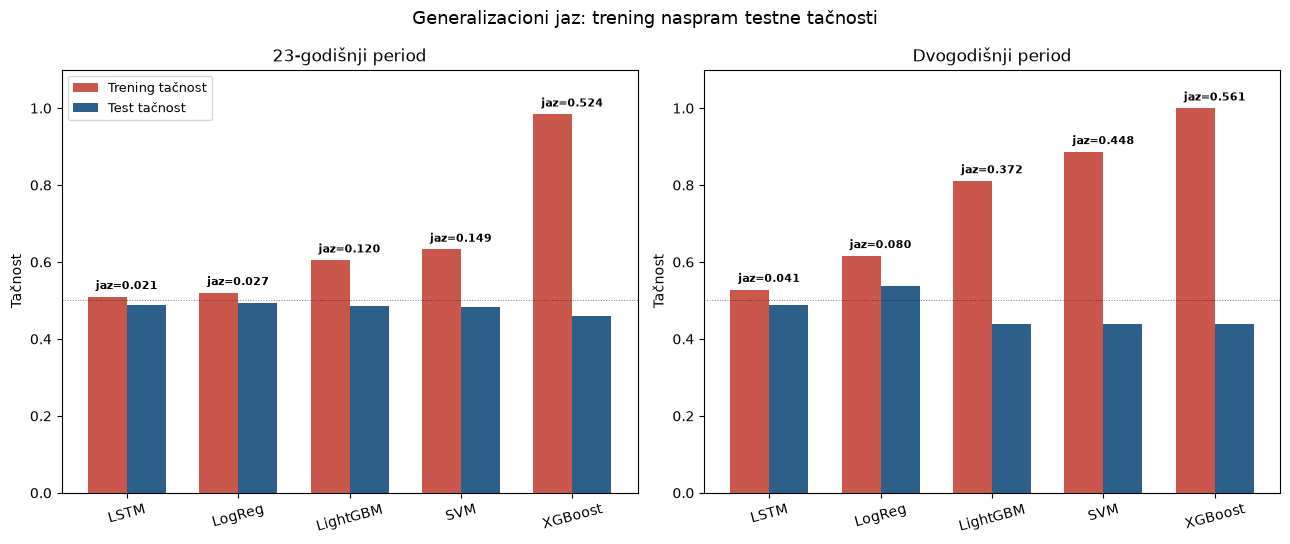

In [24]:
with open(RESULTS_DIR / "summary_full_23y.json", "r", encoding="utf-8") as f:
    summary_23y = json.load(f)
with open(RESULTS_DIR / "summary_short_2y.json", "r", encoding="utf-8") as f:
    summary_2y = json.load(f)

display_names = {'logreg': 'LogReg', 'svm': 'SVM', 'xgboost': 'XGBoost',
                  'lightgbm': 'LightGBM', 'lstm': 'LSTM'}

def extract_generalization(summary):
    """Vraca rjecnik model -> (train_acc, val_acc, test_acc, gap) iz generalization_table."""
    out = {}
    for row in summary['generalization_table']:
        out[row['model']] = (
            row['train_accuracy'],
            row['val_accuracy'],
            row['test_accuracy'],
            row['train_test_gap'],
        )
    return out

data_23 = extract_generalization(summary_23y)
data_2 = extract_generalization(summary_2y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, data, title in [(axes[0], data_23, "23-godišnji period"),
                          (axes[1], data_2, "Dvogodišnji period")]:
    order = sorted(data.keys(), key=lambda m: data[m][3])  # sortirano po jazu, rastuce
    names = [display_names[m] for m in order]
    train_vals = [data[m][0] for m in order]
    test_vals = [data[m][2] for m in order]

    x = np.arange(len(names))
    width = 0.35
    ax.bar(x - width/2, train_vals, width, label='Trening tačnost', color='#c0392b', alpha=0.85)
    ax.bar(x + width/2, test_vals, width, label='Test tačnost', color='#2c5f8a')

    for xi, m in zip(x, order):
        gap = data[m][3]
        top = max(data[m][0], data[m][2])
        ax.annotate(f'jaz={gap:.3f}', xy=(xi, top + 0.02),
                    ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.set_ylabel('Tačnost')
    ax.axhline(0.5, color='black', linewidth=0.7, linestyle=':', alpha=0.5)

axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle('Generalizacioni jaz: trening naspram testne tačnosti', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "generalization_gap_v2.png", dpi=200, bbox_inches='tight')
print("Sačuvano u " + str(RESULTS_DIR / "figures" / "generalization_gap_v2.png"))
plt.show()

Sačuvano u C:\Users\Win\OneDrive\Desktop\Analiza\results\figures\subperiod_accuracy_v2.png


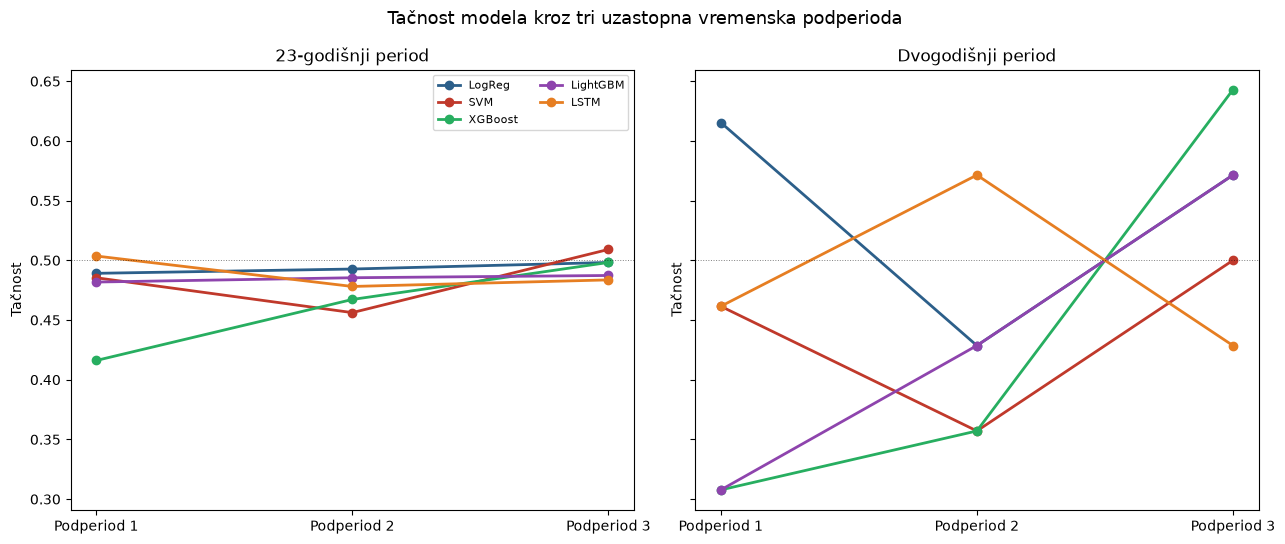

In [25]:
with open(RESULTS_DIR / "summary_full_23y.json", "r", encoding="utf-8") as f:
    summary_23y = json.load(f)
with open(RESULTS_DIR / "summary_short_2y.json", "r", encoding="utf-8") as f:
    summary_2y = json.load(f)

display_names = {'logreg': 'LogReg', 'svm': 'SVM', 'xgboost': 'XGBoost',
                  'lightgbm': 'LightGBM', 'lstm': 'LSTM'}
colors = {'logreg': '#2c5f8a', 'svm': '#c0392b', 'xgboost': '#27ae60',
          'lightgbm': '#8e44ad', 'lstm': '#e67e22'}

# Samo pet testiranih modela (bez baseline-a), redoslijed dosljedan ostatku poglavlja
models_order = ['logreg', 'svm', 'xgboost', 'lightgbm', 'lstm']

def extract_subperiods(summary, models):
    """Vraca rjecnik model -> lista accuracy po podperiodu (1,2,3)."""
    sub = summary['subperiod_accuracy']
    out = {}
    for m in models:
        periods = sorted(sub[m], key=lambda p: p['period'])
        out[m] = [p['accuracy'] for p in periods]
    return out

data_23 = extract_subperiods(summary_23y, models_order)
data_2 = extract_subperiods(summary_2y, models_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax, data, title in [(axes[0], data_23, "23-godišnji period"),
                          (axes[1], data_2, "Dvogodišnji period")]:
    x = [1, 2, 3]
    for m in models_order:
        ax.plot(x, data[m], marker='o', label=display_names[m], color=colors[m], linewidth=2)
    ax.axhline(0.5, color='black', linewidth=0.7, linestyle=':', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Podperiod 1', 'Podperiod 2', 'Podperiod 3'])
    ax.set_title(title)
    ax.set_ylabel('Tačnost')

axes[0].legend(loc='best', fontsize=8, ncol=2)
fig.suptitle('Tačnost modela kroz tri uzastopna vremenska podperioda', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "subperiod_accuracy_v2.png", dpi=200, bbox_inches='tight')
print("Sačuvano u " + str(RESULTS_DIR / "figures" / "subperiod_accuracy_v2.png"))
plt.show()

In [27]:
FEATURE_COLUMNS = [
    "Return",
    "SMA_ratio",
    "Volatility_5D",
    "Momentum_10D",
    "Daily_Range",
    "RSI_14",
    "CPI_YoY",
    "UNRATE_Diff",
    "Rate_Differential_Change",
]


def get_logreg_coefficients(
    csv_path,
    C_value,
    train_fraction=0.70,
    val_fraction=0.15,
    gap=1,
):
    df = pd.read_csv(csv_path)

    required_columns = FEATURE_COLUMNS + ["target"]
    missing_columns = [
        column for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Nedostaju kolone u CSV-u: {missing_columns}"
        )

    n_total = len(df)
    n_train = int(n_total * train_fraction)
    n_val = int(n_total * val_fraction)
    trainval_end = n_train + n_val

    if trainval_end <= gap:
        raise ValueError(
            f"Previše mali dataset: {n_total} redova."
        )

    trainval_df = df.iloc[:trainval_end].copy()

    if gap > 0:
        trainval_df = trainval_df.iloc[:-gap]

    X = trainval_df[FEATURE_COLUMNS]
    y = trainval_df["target"].astype(int)

    model_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=C_value,
                random_state=42,
                max_iter=1000,
            ),
        ),
    ])

    model_pipeline.fit(X, y)

    classifier = model_pipeline.named_steps["classifier"]

    coefficients = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "coefficient": classifier.coef_[0],
    })

    coefficients = coefficients.sort_values(
        "coefficient",
        key=lambda column: column.abs(),
        ascending=False,
    )

    print(f"Intercept (β0): {classifier.intercept_[0]:.10f}")
    print(f"Broj trening redova: {len(trainval_df)}")
    print(coefficients.to_string(index=False))
    print()

    return coefficients


print("=== 23-GODIŠNJI PERIOD ===")

coefs_23 = get_logreg_coefficients(
    "C:/Users/Win/OneDrive/Desktop/Analiza/data/processed/model_df_full_23y.csv",
    C_value=10,
)


print("=== DVOGODIŠNJI PERIOD ===")

coefs_2 = get_logreg_coefficients(
    "C:/Users/Win/OneDrive/Desktop/Analiza/data/processed/model_df_short_2y.csv",
    C_value=100,
)

=== 23-GODIŠNJI PERIOD ===
Intercept (β0): -0.0100247104
Broj trening redova: 4653
                 feature  coefficient
            Momentum_10D    -0.135453
               SMA_ratio     0.083278
                 CPI_YoY    -0.057596
                  Return    -0.055019
             UNRATE_Diff     0.032576
                  RSI_14    -0.002371
Rate_Differential_Change    -0.001769
           Volatility_5D     0.001403
             Daily_Range    -0.000098

=== DVOGODIŠNJI PERIOD ===
Intercept (β0): -0.0367709898
Broj trening redova: 224
                 feature  coefficient
                  RSI_14    -0.516330
               SMA_ratio     0.326934
           Volatility_5D     0.214909
             Daily_Range     0.159297
            Momentum_10D    -0.126661
                 CPI_YoY     0.020867
                  Return    -0.019699
             UNRATE_Diff    -0.017562
Rate_Differential_Change     0.006352

